# core

> Read, search, and visually preview PDFs with `fitz` (PyMuPDF)

In [ ]:
#| default_exp core

fastfitz is a small ergonomic layer over [PyMuPDF](https://pymupdf.readthedocs.io/) for working with PDFs interactively -- in Jupyter, solveit, or an AI-driven kernel. The design rule: reach for *text* first (cheap, precise), and for *pixels* only when layout matters. When you do need pixels, previews should be searchable and croppable so you render just the region you care about, not whole pages.

Note that PyMuPDF is AGPL-3.0 licensed, and therefore so is fastfitz.

In [ ]:
#| export
import fitz
from functools import reduce
from operator import or_
from fastcore.utils import *
from IPython.display import Image

In [ ]:
from fastcore.test import *

## A sample document

We build a small two-page PDF right here, so the demos below are deterministic and self-contained.

In [ ]:
smpl = fitz.open()
for lines in (['CERTIFICATE OF INCORPORATION','OF','EXAMPLE CORP','a Delaware corporation'],
              ['ARTICLE ONE','The name of the corporation is','Example Corp']):
    pg = smpl.new_page()
    for j,l in enumerate(lines): pg.insert_text((72, 92+24*j), l, fontsize=14)
pg0 = smpl[0]

## Text

Most questions about a PDF are answered by its text. `Document.text` gives the whole document (or chosen pages) in one string, with page markers so line references stay grounded.

In [ ]:
#| export
@patch
def text(self:fitz.Document, pages=None)->str:
    "Plain text of `pages` (default: all), with `--- page N ---` separators"
    ps = list(self) if pages is None else [self[i] for i in pages]
    return '\n'.join(f'--- page {p.number} ---\n{p.get_text().rstrip()}' for p in ps)

In [ ]:
t = smpl.text()
assert 'CERTIFICATE OF INCORPORATION' in t and '--- page 1 ---' in t
assert 'ARTICLE ONE' not in smpl.text(pages=[0])
print(t)

--- page 0 ---
CERTIFICATE OF INCORPORATION
OF
EXAMPLE CORP
a Delaware corporation
--- page 1 ---
ARTICLE ONE
The name of the corporation is
Example Corp


## Search

`Page.search_for` returns the rects where a string appears; we lift it to the document level, returning `(page, rects)` pairs for pages with hits. The rects are the bridge between text and pixels: find something textually, then render exactly where it lives.

In [ ]:
#| export
@patch
def search_for(self:fitz.Document, q)->list:
    "`(page, rects)` for each page where `q` matches; pages without hits are dropped"
    return [(p, r) for p in self if (r := p.search_for(q))]

In [ ]:
hits = smpl.search_for('corporation')
test_eq([p.number for p,_ in hits], [0, 1])
test_eq(smpl.search_for('nonexistent'), [])
hits

[(page 0 of <None, doc# 1>,
  [Rect(205.0139923095703, 76.94999694824219, 309.2439880371094, 96.18599700927734),
   Rect(146.6900177001953, 148.9499969482422, 216.71800231933594, 168.18600463867188)]),
 (page 1 of <None, doc# 1>,
  [Rect(177.83999633789062, 100.94999694824219, 247.86798095703125, 120.18599700927734)])]

## Preview

`Page.preview` renders to a PNG `Image` in three modes: the whole page, a `clip` rect, or -- the interesting one -- the union of the rects matching a query `q`. Since `search_for` returns one rect per line, the union spans line breaks, so a match that wraps still comes back as one readable crop.

The default `dpi=150` puts a US Letter page at ~1650px on the long edge: comfortably readable for vision models while staying cheap. Drop it lower for thumbnails, raise it for fine print.

In [ ]:
#| export
@patch
def preview(self:fitz.Page, q=None, clip=None, dpi=150):
    "Render as a PNG `Image`: the whole page, a `clip` rect, or the union of rects matching `q`"
    if q:
        rects = self.search_for(q)
        if not rects: raise ValueError(f'{q!r} not found on page {self.number}')
        clip = reduce(or_, rects)
    return Image(data=self.get_pixmap(dpi=dpi, clip=clip).tobytes('png'))

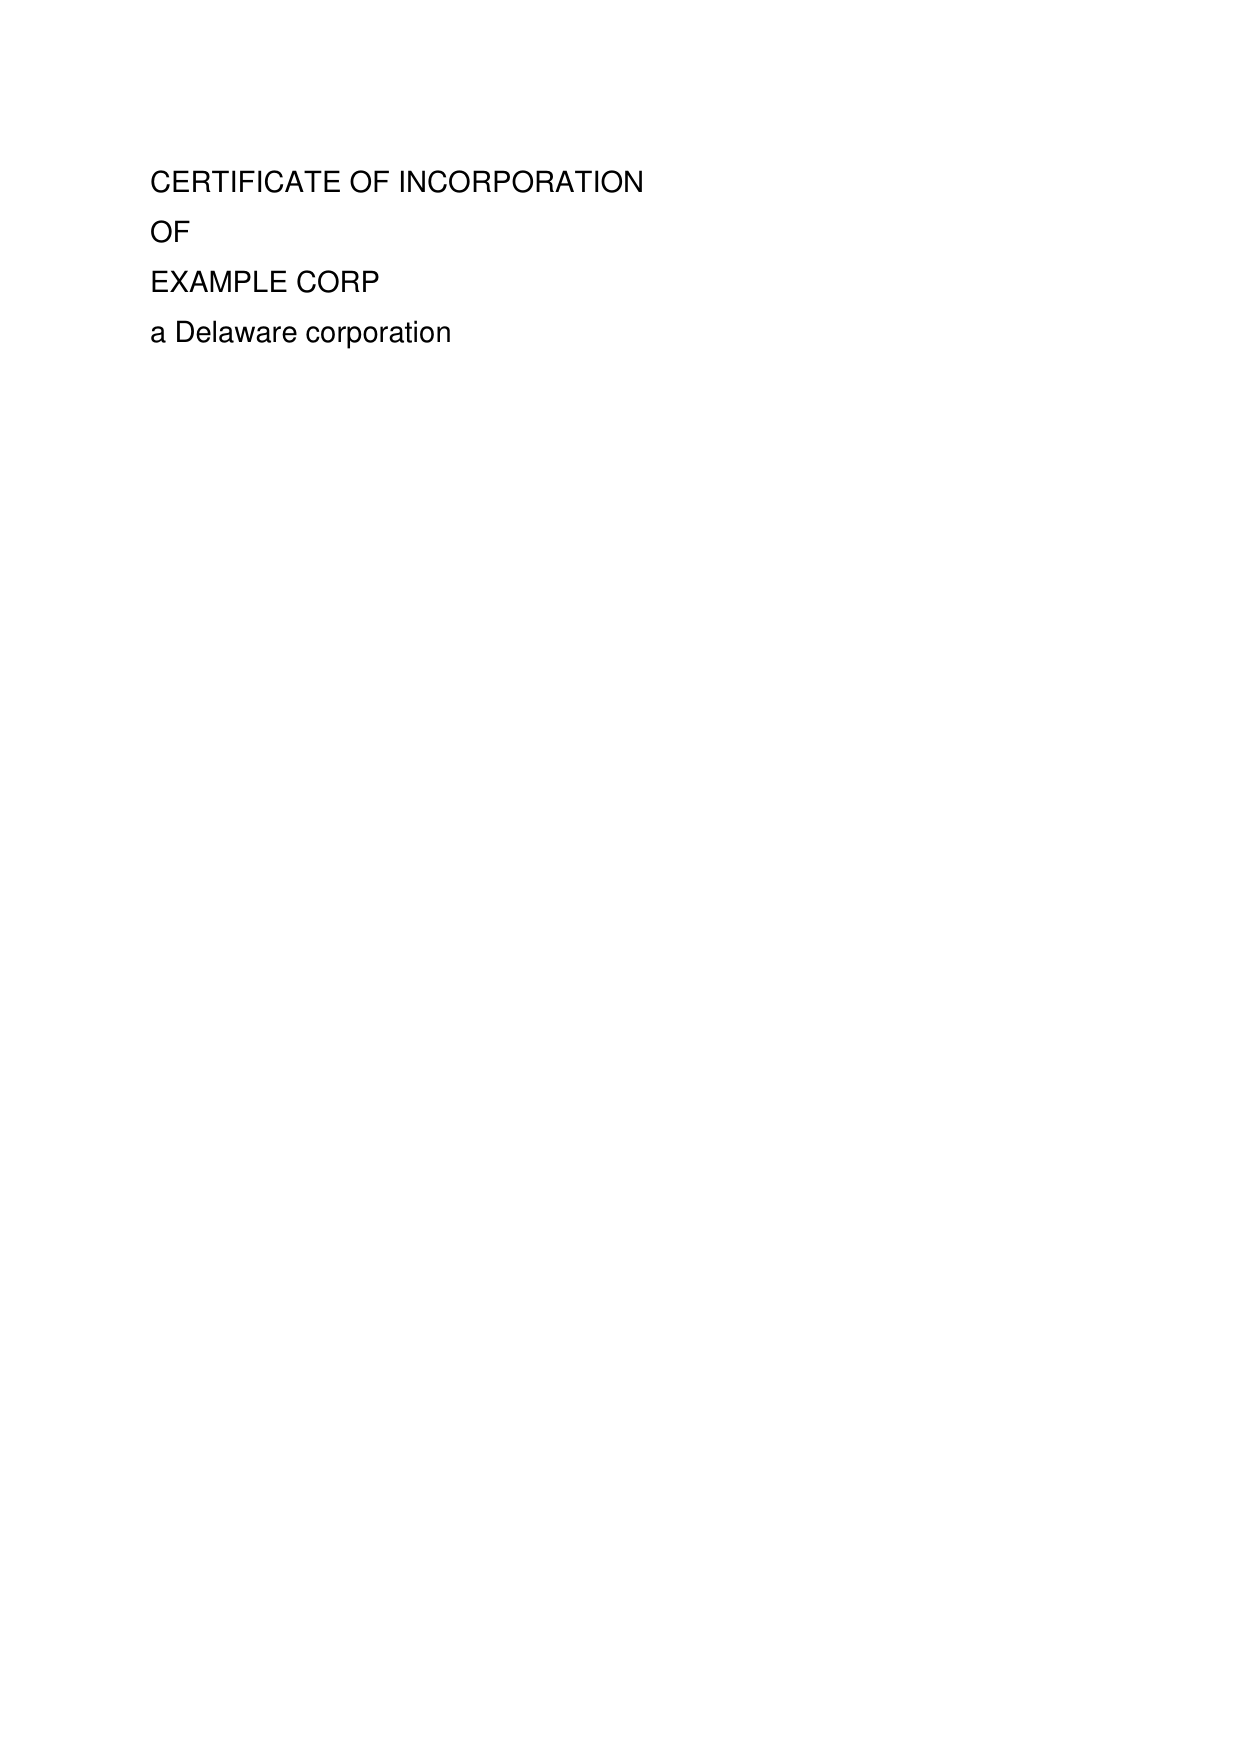

In [ ]:
assert pg0.preview().data[:8] == b'\x89PNG\r\n\x1a\n'
test_fail(lambda: pg0.preview('missing text'), contains='not found')
pg0.preview()

The query mode crops to just the matched region:

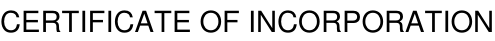

In [ ]:
pg0.preview('CERTIFICATE OF INCORPORATION')

...and an explicit `clip` renders any rect you like:

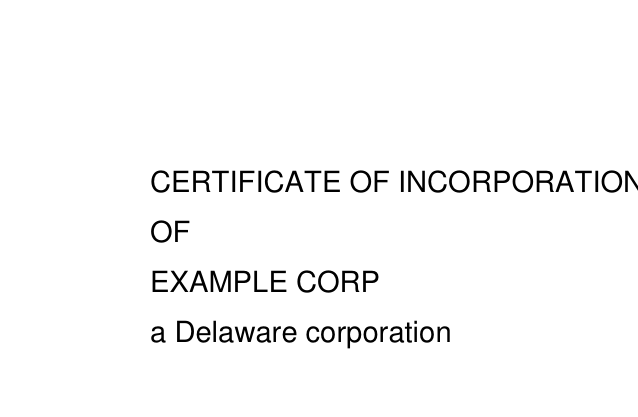

In [ ]:
pg0.preview(clip=fitz.Rect(0, 0, 306, 200))

### Pages display themselves

With a `_repr_png_`, a bare `Page` expression renders visually in any rich frontend.

In [ ]:
#| export
@patch
def _repr_png_(self:fitz.Page): return self.preview().data

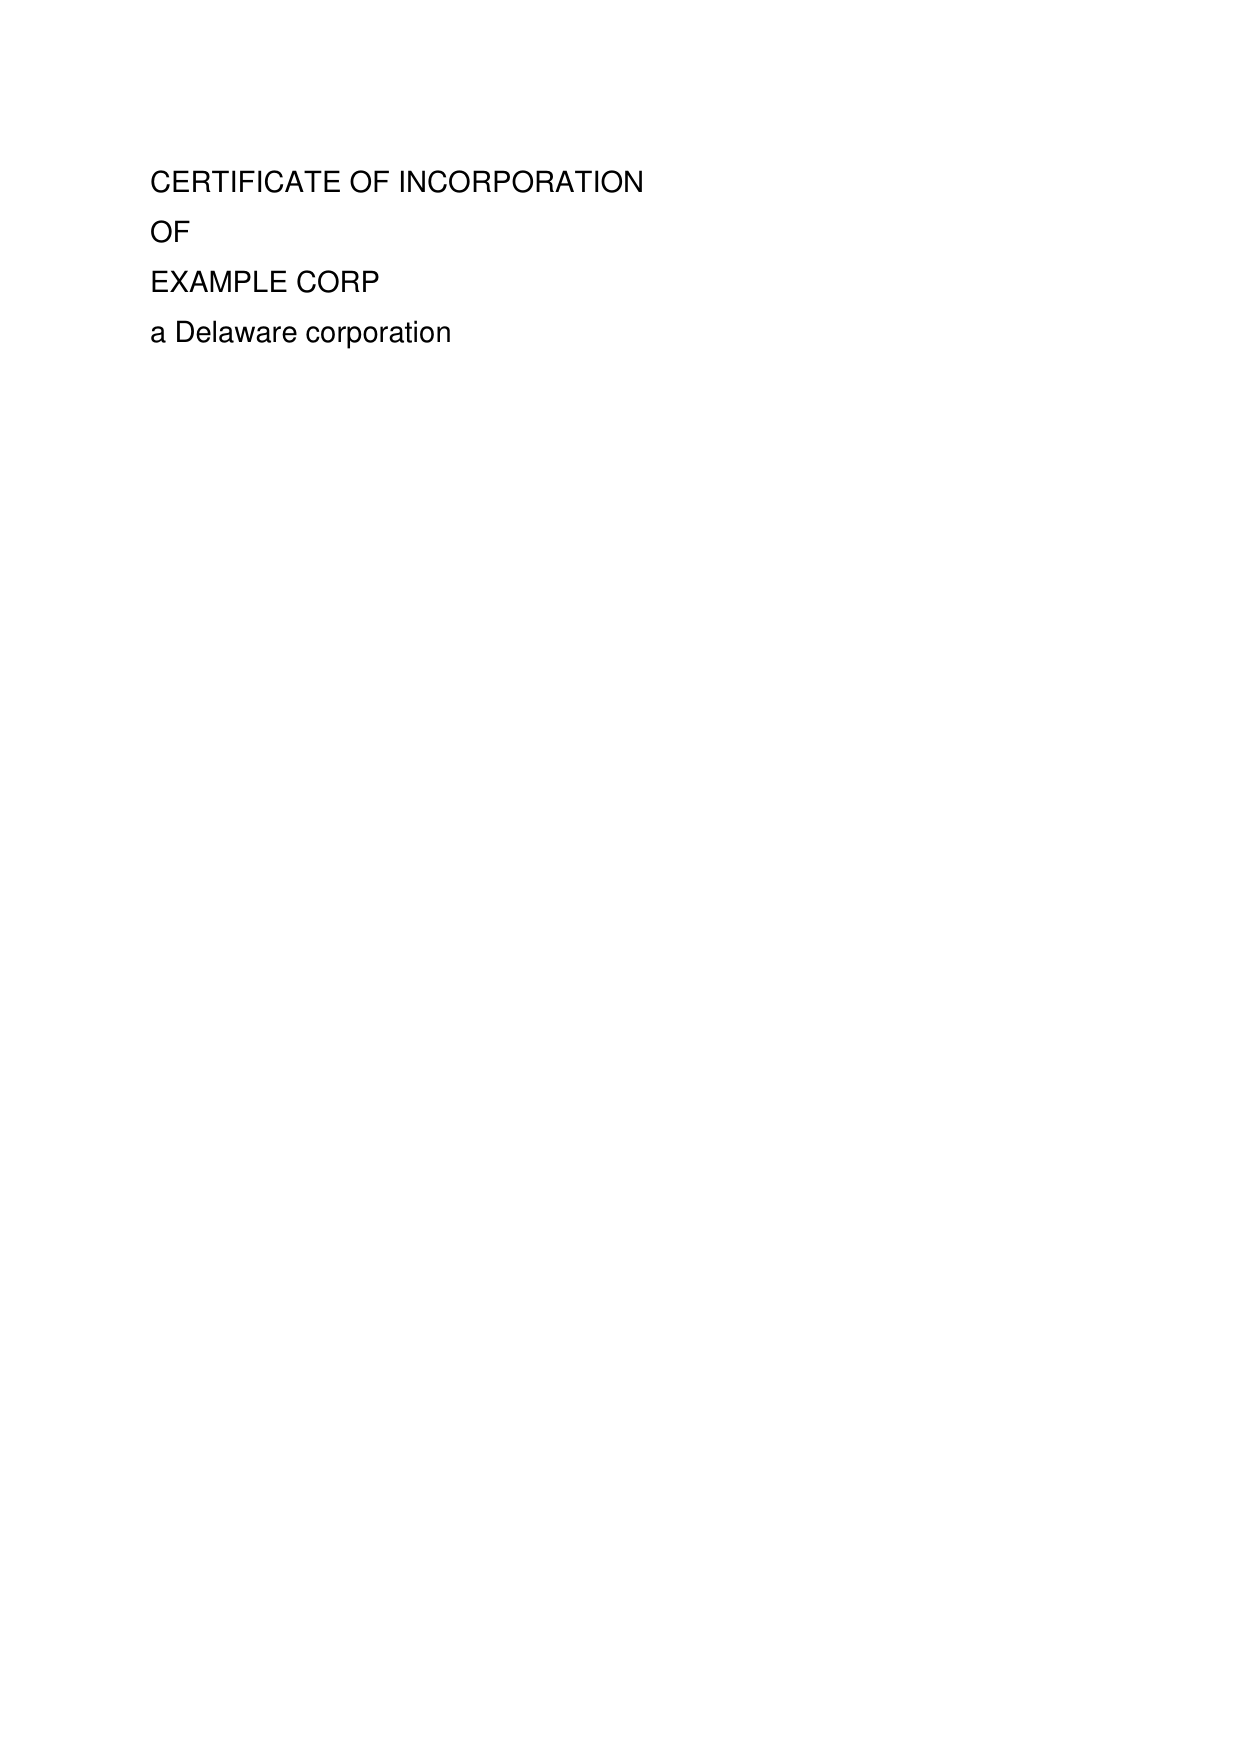

In [ ]:
assert pg0._repr_png_()[:8] == b'\x89PNG\r\n\x1a\n'
pg0

The idioms compose: search the document, preview the hit.

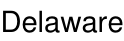

In [ ]:
p,_ = smpl.search_for('Delaware')[0]
p.preview('Delaware')

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()